# Vanilla European Call Option

**Notebook 3** of a series implementing **Stamatopoulos et al., *"Option Pricing using Quantum Computers"*** [arXiv:1905.02666](https://arxiv.org/abs/1905.02666), Section 4.1.1.

A companion write-up is available on [Medium Blog](https://medium.com/@arpitha.rajeev37/implementing-option-pricing-using-quantum-computers-in-qiskit-part-3-the-a-operator-in-8cac39179848).

Notebooks 1-2 built QFT, QPE, and Amplitude Estimation's A/Q machinery in the abstract. This notebook applies all of it to a real financial instrument: a **vanilla European call option** — the simplest option type, and the paper's own primary worked example.

**What this notebook does:**
1. **Component 1 — distribution loading**: encode a discretized probability distribution of future asset prices into qubit amplitudes, built without library (binary-tree `Ry` rotations) and compared structurally against `LogNormalDistribution's` internal gate decomposition, confirming the same recursive binary-splitting strategy.
2. **Component 2 — payoff circuit**: a quantum comparator (checks price against strike) plus a controlled payoff rotation and verified numerically against a classical ground truth, Library component for comparator `IntegerComparator` is also shown.
3. **Component 3 — Amplitude Estimation**: wire the full `A` operator into all three AE variants and recover the expected payoff.
4. **Ground-truth verification** at every stage against an independently, classically computed expected value.
5. Map → Optimize → Execute → Post-process on real hardware.

## Setup

In [70]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import IntegerComparator
from qiskit.quantum_info import Statevector
from qiskit_finance.circuit.library import LogNormalDistribution
from qiskit_algorithms import (
    EstimationProblem,
    AmplitudeEstimation,
    IterativeAmplitudeEstimation,
    MaximumLikelihoodAmplitudeEstimation,
)
from qiskit.primitives import StatevectorSampler

## The contract

A European call option: the buyer pays a premium today for the right to buy the underlying asset at strike price $K$ on the maturity date. If the asset's price $S_T$ at maturity exceeds $K$, the payoff is $S_T - K$; otherwise it is $0$.

$$f(S_T) = \max(0,\, S_T - K)$$

Pricing the option means computing $\mathbb{E}_P[f(S_T)]$ — the expected payoff across every possible future price, weighted by its probability under the assumed price distribution $P$ (here, log-normal, following the Black-Scholes-Merton model).

## Choosing concrete numbers

For a hand-verifiable first pass, use 2 qubits (4 discretized price levels) with a small, chosen probability table.

In [71]:
prices = [30, 40, 50, 60]
probs = [0.3, 0.2, 0.1, 0.4]
K = 42

assert abs(sum(probs) - 1.0) < 1e-9

# classical ground truth: brute-force expected payoff
expected_payoff_truth = sum(p * max(0, price - K) for price, p in zip(prices, probs))
print('Ground truth expected payoff:', expected_payoff_truth)

Ground truth expected payoff: 8.0


## Component 1: distribution loading

We split the distribution recursively: the top-index qubit divides the 4 prices into two halves, then the bottom qubit splits each half further. Each split angle follows $\theta = 2\arcsin\sqrt{p}$, where $p$ is the (conditional) probability of landing in the $|1\rangle$ branch.

**Convention**: the *highest-index* qubit performs the coarsest split, so that Qiskit's natural little-endian bitstring-to-integer reading lines up directly with increasing price.

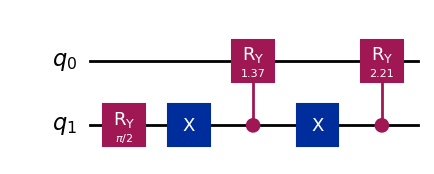

In [72]:
def tree_angles(probs):
    p_high_group = probs[2] + probs[3]
    theta_top = 2 * np.arcsin(np.sqrt(p_high_group))
    p_low_group = probs[0] + probs[1]
    theta_low_cond = 2 * np.arcsin(np.sqrt(probs[1] / p_low_group))
    theta_high_cond = 2 * np.arcsin(np.sqrt(probs[3] / p_high_group))
    return theta_top, theta_low_cond, theta_high_cond

theta_top, theta_low, theta_high = tree_angles(probs)

qc_dist = QuantumCircuit(2)  # q1 = coarse split, q0 = fine split
qc_dist.ry(theta_top, 1)
qc_dist.x(1)
qc_dist.cry(theta_low, 1, 0)
qc_dist.x(1)
qc_dist.cry(theta_high, 1, 0)

qc_dist.draw('mpl')

### Verifying against the hand-computed probability table

In [73]:
sv_dist = Statevector(qc_dist)
result_dist = sv_dist.probabilities_dict()
print(result_dist)

for label, prob in sorted(result_dist.items()):
    idx = int(label, 2)
    print(f'{label}: price={prices[idx]}, got P={prob:.4f}, expected P={probs[idx]:.4f}, '
          f'match={np.isclose(prob, probs[idx])}')

{np.str_('00'): np.float64(0.29999999999999993), np.str_('01'): np.float64(0.19999999999999998), np.str_('10'): np.float64(0.10000000000000007), np.str_('11'): np.float64(0.4)}
00: price=30, got P=0.3000, expected P=0.3000, match=True
01: price=40, got P=0.2000, expected P=0.2000, match=True
10: price=50, got P=0.1000, expected P=0.1000, match=True
11: price=60, got P=0.4000, expected P=0.4000, match=True


### Cross-checking against Qiskit's `LogNormalDistribution`

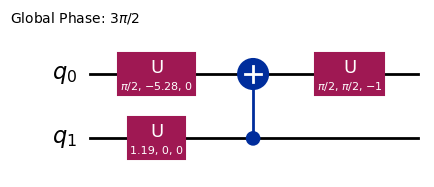

In [74]:
# LogNormalDistribution builds an isometry-based loading circuit for an
# actual log-normal curve, rather than an arbitrary hand-picked table.
# Decomposing it shows the same underlying strategy: recursive, multiplexed
# rotations -- just synthesized generally instead of derived by hand.
dist_lognormal = LogNormalDistribution(num_qubits=2, mu=0, sigma=1, bounds=(0, 4))
dist_lognormal.decompose(reps=4).draw('mpl')

## Component 2: the payoff circuit, by hand

Two pieces: a **comparator** (is price $\geq K$?) and a **controlled payoff rotation** (encode $f(\text{price})$ into a qubit's amplitude, but only for the branch where the comparator says yes).

In [78]:
# Comparator: for K=42, only prices >= $50 (i.e. q1=1) qualify
# In general, a full binary comparator is needed (see IntegerComparator below).
payoffs = [max(0, p - K) for p in prices]
f_max = max(payoffs)
print('Payoffs:', payoffs, '| f_max:', f_max)

scaled_payoffs = [p / f_max for p in payoffs]
print('Scaled Payoffs: ', scaled_payoffs)

Payoffs: [0, 0, 8, 18] | f_max: 18
Scaled Payoffs:  [0.0, 0.0, 0.4444444444444444, 1.0]


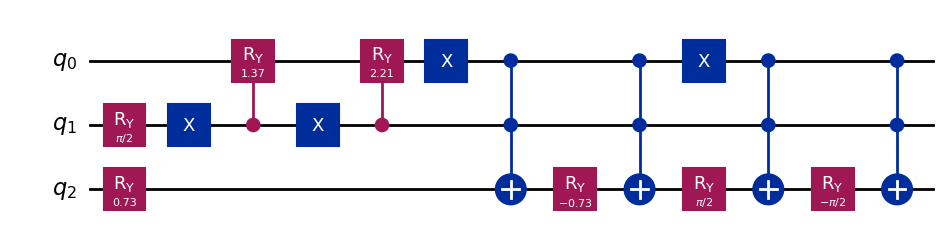

In [79]:
theta_q0_0 = 2*np.arcsin(np.sqrt(scaled_payoffs[2]))  # price=$50 (q1=1,q0=0): base rotation
theta_q0_1 = 2*np.arcsin(np.sqrt(scaled_payoffs[3]))  # price=$60 (q1=1,q0=1): needs MORE rotation

qc_A = QuantumCircuit(3)
qc_A.compose(qc_dist, qubits=[0, 1], inplace=True)

# controlled by q1 AND q0=0 (only price=$50)
qc_A.x(0)
qc_A.mcry(theta_q0_0, [0, 1], 2)
qc_A.x(0)

# controlled by q1 AND q0=1 (only price=$60)
qc_A.mcry(theta_q0_1, [0, 1], 2)

qc_A.draw("mpl")

### Verifying the full `A` operator

In [81]:
sv_A = Statevector(qc_A)
result_A = sv_A.probabilities_dict()

raw_p1 = sum(v for k, v in result_A.items() if k[0] == '1')
reconstructed_payoff = raw_p1 * f_max

print('P(payoff=1):', raw_p1)
print('Reconstructed expected payoff:', reconstructed_payoff)
print('Ground truth:                ', expected_payoff_truth)
print('Match:', np.isclose(reconstructed_payoff, expected_payoff_truth))

P(payoff=1): 0.44444444444444464
Reconstructed expected payoff: 8.000000000000004
Ground truth:                 8.0
Match: True


### Library component

`IntegerComparator` generalizes the comparator to any strike (not just ones that happen to align with an existing qubit split). Its register layout (state, compare, plus internal ancilla) matches the structure of the hand-built comparator above.

[QuantumRegister(2, 'state'), QuantumRegister(1, 'compare'), QuantumRegister(1, 'a153')]


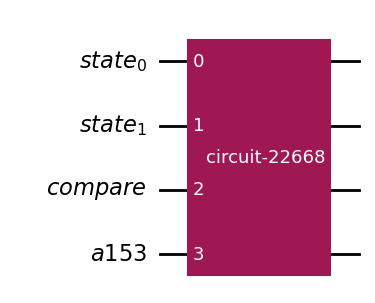

In [88]:
comparator = IntegerComparator(2, K, geq=True)
print(comparator.qregs)
comparator.draw('mpl')

## Component 3: Amplitude Estimation

Wrap `qc_A` in an `EstimationProblem` and run all three AE variants.

In [89]:
problem = EstimationProblem(
    state_preparation=qc_A,
    objective_qubits=[2],
    post_processing=lambda a: a * f_max,
)

sampler = StatevectorSampler()

ae = AmplitudeEstimation(num_eval_qubits=6, sampler=sampler)
result_ae = ae.estimate(problem)

iae = IterativeAmplitudeEstimation(epsilon_target=0.01, alpha=0.05, sampler=sampler)
result_iae = iae.estimate(problem)

mlae = MaximumLikelihoodAmplitudeEstimation(evaluation_schedule=4, sampler=sampler)
result_mlae = mlae.estimate(problem)

print(f'Ground truth:              {expected_payoff_truth:.4f}')
print(f'Canonical AE estimate:     {result_ae.estimation_processed:.4f}')
print(f'Iterative AE estimate:     {result_iae.estimation_processed:.4f}')
print(f'Maximum Likelihood AE:     {result_mlae.estimation_processed:.4f}')

Ground truth:              8.0000
Canonical AE estimate:     8.1178
Iterative AE estimate:     8.0630
Maximum Likelihood AE:     8.0102


## Convergence: error vs. number of evaluation qubits

Canonical AE's achievable estimates sit on a discrete grid determined by $M=2^m$. Sweeping $m$ shows this directly -- expect a staircase pattern (plateau, then a sharp drop), not a smooth curve, since the grid only occasionally lands close to the true value.

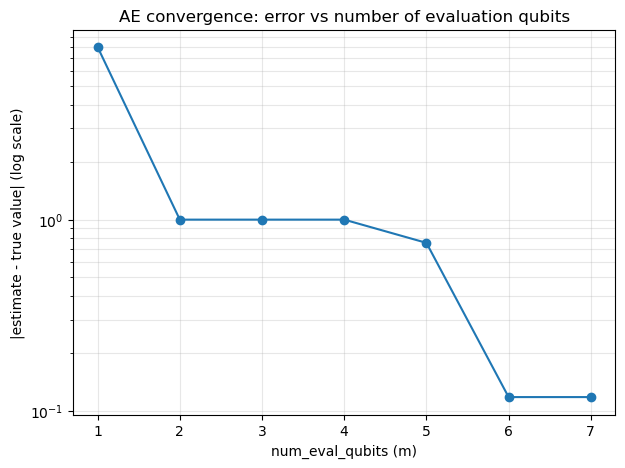

In [35]:
import matplotlib.pyplot as plt

errors = []
for m in range(1, 8):
    ae_m = AmplitudeEstimation(num_eval_qubits=m, sampler=sampler)
    res = ae_m.estimate(problem)
    errors.append(abs(res.estimation_processed - expected_payoff_truth))

plt.figure(figsize=(7, 5))
plt.plot(range(1, 8), errors, marker='o')
plt.yscale('log')
plt.xlabel('num_eval_qubits (m)')
plt.ylabel('|estimate - true value| (log scale)')
plt.title('AE convergence: error vs number of evaluation qubits')
plt.grid(True, which='both', alpha=0.3)
plt.show()

## Map → Optimize → Execute → Post-process on real hardware

In [100]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSampler
from qiskit.transpiler import generate_preset_pass_manager

# 1. Connect to Hardware
service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)
print('Using backend:', backend.name)

Using backend: ibm_marrakesh


In [102]:
# 2. Setup Pass Manager
pm_hw = generate_preset_pass_manager(optimization_level=3, backend=backend)

In [103]:
# 3. Compatible Sampler Wrapper
class HardwareTranspiledSampler:
    def __init__(self, sampler, pass_manager):
        self._sampler = sampler
        self._pm = pass_manager

    def run(self, pubs, **kwargs):
        # Transpile virtual circuits dynamically
        transpiled_pubs = []
        for pub in pubs:
            if isinstance(pub, tuple):
                circuit = self._pm.run(pub[0])
                transpiled_pubs.append((circuit, *pub[1:]))
            else:
                circuit = self._pm.run(pub)
                transpiled_pubs.append(circuit)
        
        # Execute job
        job = self._sampler.run(transpiled_pubs, **kwargs)
        
        # Intercept result to inject 'shots' into metadata for qiskit-algorithms compatibility
        original_result = job.result
        
        def patched_result(*args, **kwargs_res):
            res = original_result(*args, **kwargs_res)
            for pub_res in res:
                if "shots" not in pub_res.metadata:
                    # Get shot count from the first DataBin register
                    reg_name = next(iter(pub_res.data.keys()))
                    bit_array = getattr(pub_res.data, reg_name)
                    pub_res.metadata["shots"] = bit_array.num_shots
            return res

        job.result = patched_result
        return job

In [104]:
# 4. Initialize Hardware Sampler & Problem
base_sampler = RuntimeSampler(mode=backend)
hardware_sampler = HardwareTranspiledSampler(base_sampler, pm_hw)

problem_hw = EstimationProblem(
    state_preparation=qc_A,  # Keep virtual/untranspiled circuit
    objective_qubits=[2],
    post_processing=lambda a: a * f_max,
)

In [105]:
# 5. Run IAE
iae_hw = IterativeAmplitudeEstimation(
    epsilon_target=0.05, 
    alpha=0.05, 
    sampler=hardware_sampler
)

result_iae_hw = iae_hw.estimate(problem_hw)

print('Ground truth:                  ', expected_payoff_truth)
print('IAE estimate (real hardware): ', result_iae_hw.estimation_processed)

Ground truth:                   8.0
IAE estimate (real hardware):  8.236197023983458


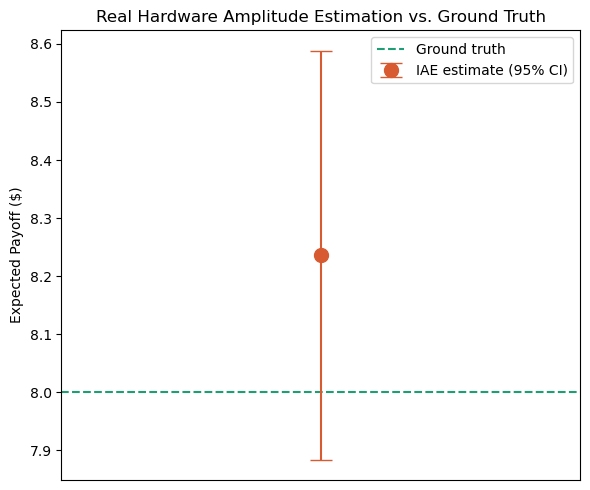

In [106]:
ci_low, ci_high = result_iae_hw.confidence_interval_processed

plt.figure(figsize=(6, 5))
plt.axhline(expected_payoff_truth, color='#1D9E75', linestyle='--', label='Ground truth')
plt.errorbar([1], [result_iae_hw.estimation_processed],
             yerr=[[result_iae_hw.estimation_processed - ci_low],
                   [ci_high - result_iae_hw.estimation_processed]],
             fmt='o', color='#D85A30', capsize=8, markersize=10,
             label='IAE estimate (95% CI)')
plt.xlim(0.5, 1.5)
plt.xticks([])
plt.ylabel('Expected Payoff ($)')
plt.title('Real Hardware Amplitude Estimation vs. Ground Truth')
plt.legend()
plt.tight_layout()
plt.show()

## Results Summary

- Distribution loading, built by hand via recursive binary-tree `Ry` rotations, matches the target probability table exactly.
- The `A` operator (distribution + payoff rotation), verified via exact statevector inspection, reconstructs the classical ground-truth expected payoff exactly.
- All three AE variants recover the expected payoff on the noiseless simulator, with canonical AE's convergence showing the expected discrete-grid staircase pattern rather than smooth decay.
- The same pipeline runs on real hardware via the standard Map → Optimize → Execute → Post-process workflow.

## What's Next

**Notebook 4** extends the payoff circuit to **portfolios of options** (e.g. a call spread with two strikes) -- the same comparator + controlled-rotation building block, stacked once per strike. **Notebook 5** introduces the one new tool needed for multi-asset and path-dependent options: a **quantum weighted-sum (adder) operator**, setting up basket and Asian options.